# Загрузка данных и библиотек
---

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import copy

RANDOM_STATE = 0xDEF

In [ ]:
train_raw = pd.read_csv('./data/train.csv')
test_raw = pd.read_csv('./data/test.csv')

train = train_raw.copy()
test = test_raw.copy()

# EDA
---

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Посмотрим на распределение таргета `SalePrice`

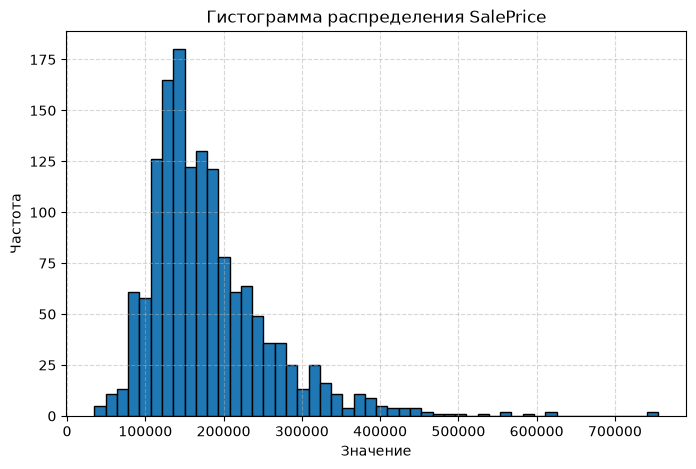

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(train['SalePrice'], bins=50, edgecolor='black')

plt.title('Гистограмма распределения SalePrice')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Видим, что распределение нессиметрично, попробуем взять log от величины

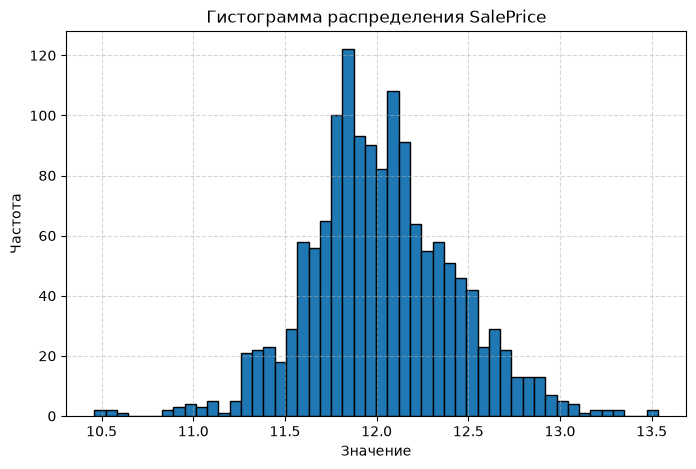

In [5]:
train['SalePrice_log'] = np.log1p(train['SalePrice'])

plt.figure(figsize=(8, 5))
plt.hist(train['SalePrice_log'], bins=50, edgecolor='black')

plt.title('Гистограмма распределения SalePrice')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

График стал более симметричным и похожим на нормальное распределение

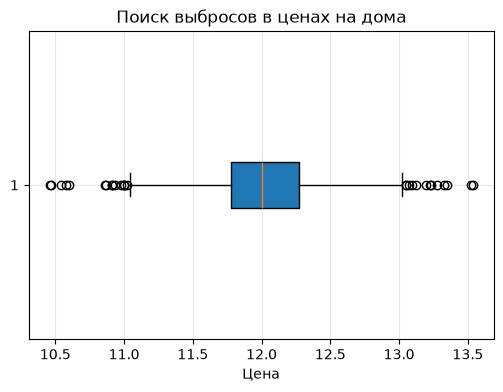

In [6]:
plt.figure(figsize=(6, 4))
plt.boxplot(train['SalePrice_log'], orientation='horizontal', patch_artist=True)
plt.title('Поиск выбросов в ценах на дома')
plt.xlabel('Цена')
plt.grid(True, alpha=0.3)
plt.show()

### Анализ пропусков

In [ ]:
with pd.option_context('display.max_rows', None):
    print(train.isna().sum()[train.isna().sum() > 0].sort_values())

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64


Рассмотрим пропуски для `PoolQC`, вполне возможно пропуски означают отсутствие объекта

In [ ]:
print((train[train['PoolQC'].isna()].index != train[train['PoolArea'] == 0].index).sum())

0


ВЫВОД: пропуски в `PoolQC` означают отсутствие объекта. Такая же ситуация и в других признаках

# Предобработка данных
---

In [ ]:
train = train_raw.copy()
test  = test_raw.copy()

df = pd.concat([train, test], sort=False).reset_index(drop=True)
train_mask = df['SalePrice'].notna()

### Заполнение пропусков

In [10]:
total = df.isna().sum()
percent = np.round((df.isna().sum() / df.shape[0]) * 100, 2)

missing_df = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_df.drop('SalePrice', inplace=True)
display(missing_df[missing_df['Total'] > 0].sort_values(by='Total', ascending=False))

,Total,Percent
PoolQC,2909,99.66
MiscFeature,2814,96.40
Alley,2721,93.22
Fence,2348,80.44
MasVnrType,1766,60.50
FireplaceQu,1420,48.65
LotFrontage,486,16.65
GarageQual,159,5.45
GarageYrBlt,159,5.45
GarageCond,159,5.45


Для категориальных признаков отсутствие объекта вместо `NaN` заполним строкой `"None"`

In [ ]:
none_columns_categorical = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType',
]
for col in none_columns_categorical:
    df[col] = df[col].fillna('None')

А для числовых признаков - заполним нулём

In [ ]:
none_columns_numeric = [
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea',
]
for col in none_columns_numeric:
    df[col] = df[col].fillna(0)

Пропуски `GarageYrBlt` можно заменить годом постройки дома `YearBuilt`

In [ ]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

Пропуски `LotFrontage` можно заменить медианой внутри `Neighborhood`

In [ ]:
train_medians = df[train_mask].groupby('Neighborhood')['LotFrontage'].median()
df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(train_medians))
df['LotFrontage'] = df['LotFrontage'].fillna(df.loc[train_mask, 'LotFrontage'].median())

Оставшиеся единичные пропуски можно заменить модой

In [ ]:
mode_fill_columns = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd', 'Electrical', 'KitchenQual', 'SaleType']
for col in mode_fill_columns:
    train_mode = df.loc[train_mask, col].mode()[0]
    df[col] = df[col].fillna(train_mode)

### Преобразования

Переведем `MSSubClass` в категориальный признак

In [ ]:
df['MSSubClass'] = df['MSSubClass'].astype('category')

Рассмотрим статистику по категориальным признакам

In [ ]:
categorical_stats = df.describe(include=['object', 'category', 'str'])

with pd.option_context('display.max_columns', None):
    display(categorical_stats)

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919
unique,16,5,2,3,4,4,2,5,3,25,9,8,5,8,6,8,15,16,4,4,5,6,5,5,5,7,7,6,5,2,5,4,7,6,7,4,6,6,3,4,5,5,9,6
top,20,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,None,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,None,Attchd,Unf,TA,TA,Y,None,None,None,WD,Normal
freq,1079,2269,2907,2721,1859,2622,2918,2133,2778,443,2511,2889,2425,1471,2310,2876,1026,1015,1766,1798,2538,1308,1283,2606,1904,851,2493,2874,1493,2723,2672,1493,2719,1420,1723,1230,2604,2654,2641,2909,2348,2814,2526,2402


In [ ]:
exclude_columns = ['Id', 'SalePrice']

THRESHOLD = 6

num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features = [col for col in num_features if col not in exclude_columns]

cat_columns = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
cat_columns = [col for col in cat_columns if col not in exclude_columns]

ohe_features = []
target_features = []

for col in cat_columns:
    n_unique = df.loc[train_mask, col].nunique()
    if n_unique <= THRESHOLD:
        ohe_features.append(col)
    else:
        target_features.append(col)

In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def target_encode_cv(df, train_mask, target_features, y, cv, smoothing=10):
    df = df.copy()
    global_mean = y.mean()
    train_idx = df.index[train_mask]
    test_idx = df.index[~train_mask]

    for col in target_features:
        encoded = pd.Series(index=df.index, dtype=float)

        # Train: честные OOF-значения
        for tr_pos, val_pos in cv.split(train_idx):
            fold_train_idx = train_idx[tr_pos]
            fold_val_idx = train_idx[val_pos]

            stats = pd.DataFrame({'y': y.loc[fold_train_idx], 'cat': df.loc[fold_train_idx, col]}) \
                        .groupby('cat')['y'].agg(['mean', 'count'])
            smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)

            encoded.loc[fold_val_idx] = df.loc[fold_val_idx, col].map(smoothed)

        # категории, не встретившиеся в конкретном обучающем фолде, заполняем глобальным средним
        encoded.loc[train_idx] = encoded.loc[train_idx].fillna(global_mean)

        # Test: кодируем средним по всему train
        stats_full = pd.DataFrame({'y': y, 'cat': df.loc[train_idx, col]}).groupby('cat')['y'].agg(['mean', 'count'])
        smoothed_full = (stats_full['count'] * stats_full['mean'] + smoothing * global_mean) / (stats_full['count'] + smoothing)
        encoded.loc[test_idx] = df.loc[test_idx, col].map(smoothed_full).fillna(global_mean)

        df[col + '_te'] = encoded

    return df.drop(columns=target_features)

In [20]:
df = df.drop(columns=['Id'])
df_cat = df.copy()
df = pd.get_dummies(df, columns=ohe_features)
df = target_encode_cv(df, train_mask, target_features, y=df.loc[train_mask, 'SalePrice'], cv=cv, smoothing=10)

In [ ]:
train, test = df[train_mask].copy(), df[~train_mask].copy()
train_cat, test_cat = df_cat[train_mask].copy(), df_cat[~train_mask].copy()
test = test.drop(columns=['SalePrice'])
test_cat = test_cat.drop(columns=['SalePrice'])

X = train.drop('SalePrice', axis=1)
y = train['SalePrice']
X_cat = train_cat.drop('SalePrice', axis=1)
y_cat = train_cat['SalePrice']

# Classic ML
---

Функция для обучения моделей

In [ ]:
def run_model(name, estimator, X, y, cv, needs_scaling=False, fit_params=None, stats=None):
    fit_params = fit_params or {}
    y_log = np.log1p(y)
    oof_preds = np.zeros(len(y))
    fold_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]

        if needs_scaling:
            scaler = StandardScaler()
            X_tr, X_val = scaler.fit_transform(X_tr), scaler.transform(X_val)

        model = clone(estimator)
        model.fit(X_tr, y_tr, **fit_params)

        fold_pred = model.predict(X_val)
        oof_preds[val_idx] = fold_pred
        fold_scores.append(root_mean_squared_error(y_val, fold_pred))

    total_rmse = root_mean_squared_error(y_log, oof_preds)
    if stats is not None:
        stats[name] = total_rmse

    msg = f'{name}: OOF RMSLE = {total_rmse:.4f} | by folds: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}'
    print(msg)

    scaler_full = StandardScaler().fit(X) if needs_scaling else None
    X_full = scaler_full.transform(X) if scaler_full else X
    final_model = clone(estimator).fit(X_full, y_log, **fit_params)

    return {
        'oof_preds': oof_preds, 'model': final_model, 'scaler': scaler_full, 'fold_scores': fold_scores}

### Dummy Regressor - baseline

In [23]:
stats_stage1 = {}
results_stage1 = {}

results_stage1['dummy'] = run_model("DummyRegressor", DummyRegressor(strategy='mean'), X, y, cv, stats=stats_stage1)
dummy_model = results_stage1['dummy']['model']

DummyRegressor: OOF RMSLE = 0.3996 | by folds: 0.3993 ± 0.0160


### Linear Regression

In [24]:
def get_tuned_linear_regression(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(max_iter=20000, tol=1e-3, random_state=RANDOM_STATE))
    ])
    
    param_grid = {
        'model__alpha': np.logspace(-4, 2, 15),
        'model__l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
    }

    search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    search.fit(X, y_log)
    if verbose:
        print('Linear Regression (ElasticNet):')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
        
    return search.best_estimator_.named_steps['model']

lr_tuned = get_tuned_linear_regression(X, y, cv)

Linear Regression (ElasticNet):
                   value
model__alpha     0.26827
model__l1_ratio  0.00000


In [25]:
results_stage1['lr'] = run_model('LinearRegression', lr_tuned, X, y, cv, needs_scaling=True, stats=stats_stage1)
lr_model = results_stage1['lr']['model']

LinearRegression: OOF RMSLE = 0.1468 | by folds: 0.1451 ± 0.0224


### KNN

In [26]:
def get_tuned_knn(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor())
    ])
    param_grid = [
        {'model__n_neighbors': np.arange(1, 50), 'model__weights': ['uniform', 'distance'], 'model__metric': ['euclidean', 'manhattan']},
        {'model__n_neighbors': np.arange(1, 50), 'model__weights': ['uniform', 'distance'], 'model__metric': ['minkowski'], 'model__p': [1, 2, 3]},
    ]
    search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    search.fit(X, y_log)
    if verbose:
        print('KNeighborsRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_.named_steps['model']

knn_tuned = get_tuned_knn(X, y, cv)

KNeighborsRegressor:
                        value
model__metric       manhattan
model__n_neighbors          7
model__weights       distance


In [27]:
results_stage1['knn'] = run_model('KNeighborsRegressor', knn_tuned, X, y, cv, needs_scaling=True, stats=stats_stage1)
knn_model = results_stage1['knn']['model']

KNeighborsRegressor: OOF RMSLE = 0.1825 | by folds: 0.1823 ± 0.0096


### Decision Tree

In [28]:
def get_tuned_decision_tree(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'criterion': ['squared_error', 'absolute_error', 'poisson'],
        'max_depth': [None, 2, 3, 4, 5, 7, 10, 12, 15], 
        'min_samples_split': np.arange(2, 30, 2),
        'min_samples_leaf': np.arange(1, 20, 2),
        'max_features': [None, 'sqrt', 'log2', 0.5, 0.7] 
    }

    search = RandomizedSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), 
                                param_grid, 
                                n_iter=300, 
                                cv=cv, 
                                scoring='neg_root_mean_squared_error', 
                                random_state=RANDOM_STATE, 
                                n_jobs=-1)
    search.fit(X, y_log)
    if verbose:
        print('DecisionTreeRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

tree_tuned = get_tuned_decision_tree(X, y, cv)

DecisionTreeRegressor:
                            value
min_samples_split              16
min_samples_leaf               13
max_features                 None
max_depth                      10
criterion          absolute_error


In [29]:
results_stage1['tree'] = run_model('DecisionTreeRegressor', tree_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
tree_model = results_stage1['tree']['model']

DecisionTreeRegressor: OOF RMSLE = 0.1796 | by folds: 0.1793 ± 0.0097


### Random Forest

In [30]:
def get_tuned_random_forest(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'criterion': ['squared_error', 'absolute_error', 'poisson'],
        'max_samples': [0.5, 0.7, 0.9, None],
        'max_depth': [2, 3, 4, 5],
        'max_features': ['sqrt', 'log2', 0.4, 0.6],
        'min_samples_split': [2, 4, 5, 7, 10],
        'min_samples_leaf': [1, 2, 4, 5, 7, 10],
    }

    search = RandomizedSearchCV(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE), 
                                param_grid, 
                                n_iter=100, 
                                cv=cv, 
                                scoring='neg_root_mean_squared_error', 
                                random_state=RANDOM_STATE, 
                                n_jobs=-1)
    search.fit(X, y_log)
    if verbose:
        print('RandomForestRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

rf_tuned = get_tuned_random_forest(X, y, cv)

RandomForestRegressor:
                           value
min_samples_split              7
min_samples_leaf               4
max_samples                  0.7
max_features                 0.4
max_depth                      5
criterion          squared_error


In [31]:
results_stage1['rf'] = run_model('RandomForestRegressor', rf_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
rf_model = results_stage1['rf']['model']

RandomForestRegressor: OOF RMSLE = 0.1532 | by folds: 0.1529 ± 0.0082


### CatBoost

In [32]:
def get_tuned_catboost(X, y, cv, cat_features, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'depth': [3, 4, 5, 6, 8],                
        'l2_leaf_reg': [1, 3, 5, 10, 20],
        'random_strength': [0.0, 0.2, 0.5, 1.0],
        'bagging_temperature': [0.0, 0.4, 0.8, 1.0]
    }

    model = CatBoostRegressor(loss_function='RMSE', random_seed=RANDOM_STATE, iterations=300, logging_level='Silent', allow_writing_files=False, cat_features=cat_features)
    cv_splits = list(cv.split(X, y_log))
    search = model.randomized_search(
        param_grid, X=X, y=y_log, cv=cv_splits, n_iter=40,
        partition_random_seed=RANDOM_STATE, verbose=False, plot=False
    )
    if verbose:
        print('CatBoostRegressor:')
        print(pd.DataFrame.from_dict(search['params'], orient='index', columns=['value']), end='\n')
    return model

cb_tuned = get_tuned_catboost(X_cat, y_cat, cv, cat_features=cat_columns)

CatBoostRegressor:
                     value
bagging_temperature   1.00
random_strength       0.00
depth                 3.00
learning_rate         0.05
l2_leaf_reg           1.00


In [33]:
best_params = cb_tuned.get_params()
best_params.pop('cat_features', None)
cb_template = CatBoostRegressor(**best_params)

results_stage1['cb'] = run_model('CatBoostRegressor', cb_template, X_cat, y_cat, cv, fit_params={'cat_features': cat_columns}, needs_scaling=False, stats=stats_stage1)
cb_model = results_stage1['cb']['model']

CatBoostRegressor: OOF RMSLE = 0.1291 | by folds: 0.1288 ± 0.0086


### LightGBM

In [34]:
def get_tuned_lightgbm(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'num_leaves': np.arange(5, 20, 3),
        'max_depth': [-1, 3, 5, 7],
        'min_child_samples': [10, 15, 20, 25, 30]
    }

    search = RandomizedSearchCV(LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
                                param_grid, 
                                n_iter=200, 
                                scoring='neg_root_mean_squared_error', 
                                cv=cv, 
                                n_jobs=-1, 
                                random_state=RANDOM_STATE)
    search.fit(X, y_log)
    if verbose:
        print('LGBMRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

lgbm_tuned = get_tuned_lightgbm(X, y, cv)

LGBMRegressor:
                      value
num_leaves          11.0000
n_estimators       200.0000
min_child_samples   15.0000
max_depth           -1.0000
learning_rate        0.0775


In [35]:
results_stage1['lgbm'] = run_model('LGBMRegressor', lgbm_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
lgbm_model = results_stage1['lgbm']['model']

LGBMRegressor: OOF RMSLE = 0.1276 | by folds: 0.1272 ± 0.0098


In [36]:
def get_tuned_xgboost(X, y, cv, verbose=True):
    y_log = np.log1p(y)
    param_grid = {
        'n_estimators': np.arange(50, 301, 50),
        'learning_rate': np.linspace(0.01, 0.1, 5),
        'max_depth': [3, 4, 5, 6, 7],
        'min_child_weight': [1, 2, 4, 6, 8, 10],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
    }

    search = RandomizedSearchCV(XGBRegressor(random_state=RANDOM_STATE, eval_metric='rmse', n_jobs=-1), 
                                param_grid, 
                                n_iter=100, 
                                scoring='neg_root_mean_squared_error', 
                                cv=cv, 
                                n_jobs=-1, 
                                random_state=RANDOM_STATE)
    search.fit(X, y_log)
    if verbose:
        print('XGBRegressor:')
        print(pd.DataFrame.from_dict(search.best_params_, orient='index', columns=['value']), end='\n')
    return search.best_estimator_

xgb_tuned = get_tuned_xgboost(X, y, cv)

XGBRegressor:
                    value
subsample           0.700
n_estimators      200.000
min_child_weight    4.000
max_depth           4.000
learning_rate       0.055
colsample_bytree    0.700


In [37]:
results_stage1['xgb'] = run_model('XGBRegressor', xgb_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)
xgb_model = results_stage1['xgb']['model']

XGBRegressor: OOF RMSLE = 0.1260 | by folds: 0.1257 ± 0.0093


# Итоги по Classic ML

In [38]:
def print_sorted_stats(stats):
    stats = dict(sorted(stats.items(), key=lambda x: x[1]))

    print('┌' + '─' * 24 + '┬' + '─' * 14 + '┐')
    print(f"│ {'Classifier':<22} │ {'CV RMSLE    ':<10} │")
    print('├' + '─' * 24 + '┼' + '─' * 14 + '┤')

    for model_name, accuracy in stats.items():
        print(f"│ {model_name:<22} │ {accuracy:<12.4f} │")

    print('└' + '─' * 24 + '┴' + '─' * 14 + '┘')

print_sorted_stats(stats_stage1)

┌────────────────────────┬──────────────┐
│ Classifier             │ CV RMSLE     │
├────────────────────────┼──────────────┤
│ XGBRegressor           │ 0.1260       │
│ LGBMRegressor          │ 0.1276       │
│ CatBoostRegressor      │ 0.1291       │
│ LinearRegression       │ 0.1468       │
│ RandomForestRegressor  │ 0.1532       │
│ DecisionTreeRegressor  │ 0.1796       │
│ KNeighborsRegressor    │ 0.1825       │
│ DummyRegressor         │ 0.3996       │
└────────────────────────┴──────────────┘


# Deep Learning
---

In [39]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Подготавливаем данные на вход нейросети

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X, np.log1p(y), test_size=0.2, random_state=RANDOM_STATE, shuffle=True)
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_val_scaled   = scaler_nn.transform(X_val)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_scaled,   dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

### Первая версия

In [41]:
class NN1(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 16)
        self.layer_2 = nn.Linear(16, 16)
        self.layer_3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        x = self.relu(x)
        x = self.layer_3(x)
        return x

input_dim = X_train_tensor.shape[1]
nn1_model = NN1(input_dim).to(device)

In [42]:
criterion = nn.MSELoss()
optimizer = optim.Adam(nn1_model.parameters(), lr=0.001)

In [43]:
EPOCHS = 100
train_losses, val_losses = [], []
train_rmsle, val_rmsle = [], []

for epoch in range(EPOCHS):
    nn1_model.train()
    train_loss = 0
    train_sq_error = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn1_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_sq_error += ((y_pred - y_batch) ** 2).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_rmsle.append((train_sq_error / len(y_train_tensor)) ** 0.5)

    nn1_model.eval()
    with torch.no_grad():
        y_val_pred = nn1_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()
        val_sq_error = ((y_val_pred - y_val_target) ** 2).sum().item()

    val_losses.append(val_loss)
    val_rmsle.append((val_sq_error / len(y_val_tensor)) ** 0.5)
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_rmsle: {train_rmsle[-1]:.4f} | val_rmsle: {val_rmsle[-1]:.4f}')

[EPOCH  10/100] train_rmsle: 1.4675 | val_rmsle: 1.6480
[EPOCH  20/100] train_rmsle: 0.8055 | val_rmsle: 1.3039
[EPOCH  30/100] train_rmsle: 0.5687 | val_rmsle: 1.1749
[EPOCH  40/100] train_rmsle: 0.4438 | val_rmsle: 1.1154
[EPOCH  50/100] train_rmsle: 0.3667 | val_rmsle: 1.0835
[EPOCH  60/100] train_rmsle: 0.3135 | val_rmsle: 1.0514
[EPOCH  70/100] train_rmsle: 0.2763 | val_rmsle: 1.0250
[EPOCH  80/100] train_rmsle: 0.2392 | val_rmsle: 1.0153
[EPOCH  90/100] train_rmsle: 0.2165 | val_rmsle: 0.9998
[EPOCH 100/100] train_rmsle: 0.2115 | val_rmsle: 0.9824


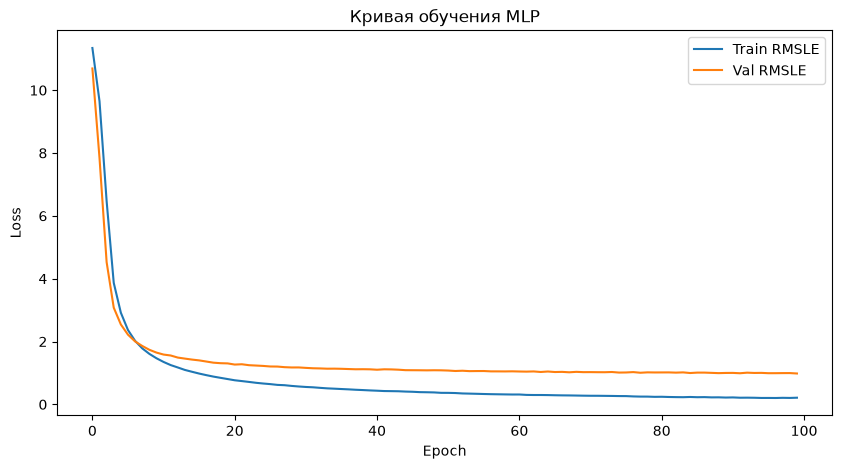

In [44]:
def plot_nn_rmsle(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train RMSLE')
    plt.plot(val_losses, label='Val RMSLE')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Кривая обучения MLP')
    plt.show()

plot_nn_rmsle(train_rmsle, val_rmsle)

In [ ]:
stats_stage1['NN1'] = min(val_rmsle)

### Добавляем BatchNorm, DropOut, Early Stopping

In [46]:
class NN2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer_2(x))))
        return self.layer_3(x)

input_dim = X_train_tensor.shape[1]
nn2_model = NN2(input_dim).to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(nn2_model.parameters(), lr=0.001, weight_decay=1e-4)

In [48]:
EPOCHS = 200
train_losses, val_losses = [], []
train_rmsle, val_rmsle = [], []

best_val_loss = float('inf')
best_model_weights = None

for epoch in range(EPOCHS):
    nn2_model.train()
    train_loss = 0
    train_sq_error = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = nn2_model(X_batch)
        y_batch = y_batch.view(-1, 1)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_sq_error += ((y_pred - y_batch) ** 2).sum().item()
    
    train_losses.append(train_loss / len(train_loader))
    train_rmsle.append((train_sq_error / len(y_train_tensor)) ** 0.5)

    nn2_model.eval()
    with torch.no_grad():
        y_val_pred = nn2_model(X_val_tensor)
        y_val_target = y_val_tensor.view(-1, 1)
        val_loss = criterion(y_val_pred, y_val_target).item()
        val_sq_error = ((y_val_pred - y_val_target) ** 2).sum().item()

    val_losses.append(val_loss)
    val_rmsle.append((val_sq_error / len(y_val_tensor)) ** 0.5)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(nn2_model.state_dict())
    
    if (epoch + 1) % 10 == 0:
        print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_rmsle: {train_rmsle[-1]:.4f} | val_rmsle: {val_rmsle[-1]:.4f}')        

[EPOCH  10/200] train_rmsle: 6.5692 | val_rmsle: 6.5566
[EPOCH  20/200] train_rmsle: 2.3327 | val_rmsle: 1.5660
[EPOCH  30/200] train_rmsle: 2.1359 | val_rmsle: 1.1110
[EPOCH  40/200] train_rmsle: 2.1037 | val_rmsle: 1.1523
[EPOCH  50/200] train_rmsle: 2.0429 | val_rmsle: 1.1789
[EPOCH  60/200] train_rmsle: 2.0315 | val_rmsle: 1.0240
[EPOCH  70/200] train_rmsle: 2.0073 | val_rmsle: 1.0731
[EPOCH  80/200] train_rmsle: 1.8971 | val_rmsle: 1.0282
[EPOCH  90/200] train_rmsle: 1.9119 | val_rmsle: 1.0144
[EPOCH 100/200] train_rmsle: 1.7847 | val_rmsle: 0.9069
[EPOCH 110/200] train_rmsle: 1.8157 | val_rmsle: 0.9012
[EPOCH 120/200] train_rmsle: 1.7881 | val_rmsle: 0.8975
[EPOCH 130/200] train_rmsle: 1.6838 | val_rmsle: 0.8672
[EPOCH 140/200] train_rmsle: 1.6938 | val_rmsle: 0.7667
[EPOCH 150/200] train_rmsle: 1.6136 | val_rmsle: 0.7980
[EPOCH 160/200] train_rmsle: 1.6624 | val_rmsle: 0.7411
[EPOCH 170/200] train_rmsle: 1.5678 | val_rmsle: 0.7381
[EPOCH 180/200] train_rmsle: 1.5271 | val_rmsle:

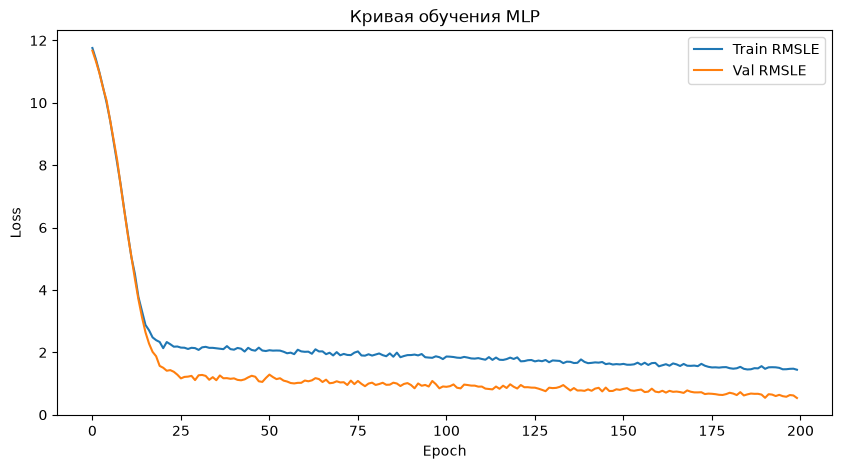

In [49]:
plot_nn_rmsle(train_rmsle, val_rmsle)

In [ ]:
stats_stage1['NN2'] = min(val_rmsle)

### Добавляем Scheduler, меняем функции активации

In [ ]:
class NN3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 56)
        self.bn1 = nn.BatchNorm1d(56)
        self.silu1 = nn.SiLU()
        self.dropout1 = nn.Dropout(0.3)

        self.layer_2 = nn.Linear(56, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.silu2 = nn.SiLU()
        self.dropout2 = nn.Dropout(0.2)

        self.layer_3 = nn.Linear(32, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.silu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.1)

        self.layer_4 = nn.Linear(16, 1)
    
    def forward(self, x):
        x = self.dropout1(self.silu1(self.bn1(self.layer_1(x))))
        x = self.dropout2(self.silu2(self.bn2(self.layer_2(x))))
        x = self.dropout3(self.silu3(self.bn3(self.layer_3(x))))
        return self.layer_4(x)

input_dim = X_train_tensor.shape[1]
nn3_model = NN3(input_dim).to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(nn3_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.1)

In [53]:
def get_fitted_nn(nn_model, train_loader, X_val, y_val, scheduler, EPOCHS, early_stopping=True, patience=50, min_delta=1e-4, verbose=True):
    train_losses, val_losses = [], []
    train_rmsle, val_rmsle = [], []
    if early_stopping:
        best_val_loss = float('inf')
        best_model_weights = None

    patience_counter = 0
    for epoch in range(EPOCHS):
        nn_model.train()
        train_loss = 0
        train_sq_error = 0
        n_train = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = nn_model(X_batch)
            y_batch = y_batch.view(-1, 1)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_sq_error += ((y_pred - y_batch) ** 2).sum().item()
            n_train += y_batch.size(0)

        train_losses.append(train_loss / len(train_loader))
        train_rmsle.append((train_sq_error / n_train) ** 0.5)

        nn_model.eval()
        with torch.no_grad():
            y_val_pred = nn_model(X_val)
            y_val_target = y_val.view(-1, 1)
            val_loss = criterion(y_val_pred, y_val_target).item()
            val_sq_error = ((y_val_pred - y_val_target) ** 2).sum().item()

        val_losses.append(val_loss)
        val_rmsle.append((val_sq_error / len(y_val)) ** 0.5)

        if early_stopping:
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_weights = copy.deepcopy(nn_model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if verbose:
                        print(f'EARLY STOPPING at epoch {epoch+1}')
                    break
        scheduler.step(val_loss)
        if verbose and (epoch + 1) % 10 == 0:
            print(f'[EPOCH {epoch+1:3}/{EPOCHS}] train_rmsle: {train_rmsle[-1]:.4f} | val_rmsle: {val_rmsle[-1]:.4f}')
    if early_stopping:
        nn_model.load_state_dict(best_model_weights)
        nn_model.eval()
    return nn_model, (train_losses, val_losses, train_rmsle, val_rmsle)


nn3_model, nn_stats = get_fitted_nn(nn3_model, train_loader, X_val_tensor, y_val_tensor, scheduler, EPOCHS=200)
train_losses, val_losses, train_rmsle, val_rmsle = nn_stats

[EPOCH  10/200] train_rmsle: 7.4630 | val_rmsle: 7.1788
[EPOCH  20/200] train_rmsle: 1.9224 | val_rmsle: 1.1994
[EPOCH  30/200] train_rmsle: 1.5096 | val_rmsle: 0.6078
[EPOCH  40/200] train_rmsle: 1.5026 | val_rmsle: 0.4545
[EPOCH  50/200] train_rmsle: 1.4303 | val_rmsle: 0.4661
[EPOCH  60/200] train_rmsle: 1.4585 | val_rmsle: 0.3695
[EPOCH  70/200] train_rmsle: 1.3897 | val_rmsle: 0.3893
[EPOCH  80/200] train_rmsle: 1.3962 | val_rmsle: 0.3653
[EPOCH  90/200] train_rmsle: 1.4253 | val_rmsle: 0.4749
[EPOCH 100/200] train_rmsle: 1.3654 | val_rmsle: 0.3771
[EPOCH 110/200] train_rmsle: 1.3902 | val_rmsle: 0.3399
[EPOCH 120/200] train_rmsle: 1.3775 | val_rmsle: 0.4133
[EPOCH 130/200] train_rmsle: 1.3667 | val_rmsle: 0.3741
[EPOCH 140/200] train_rmsle: 1.3275 | val_rmsle: 0.3928
[EPOCH 150/200] train_rmsle: 1.4289 | val_rmsle: 0.4076
[EPOCH 160/200] train_rmsle: 1.4129 | val_rmsle: 0.4291
EARLY STOPPING at epoch 161


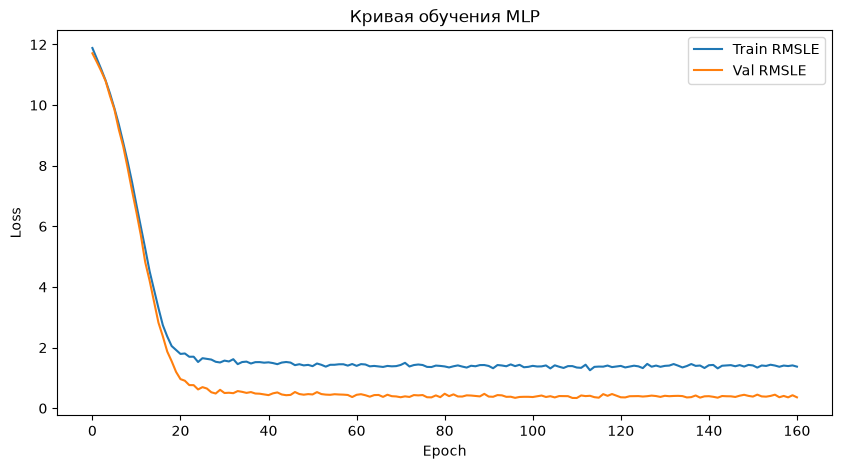

In [54]:
plot_nn_rmsle(train_rmsle, val_rmsle)

In [55]:
class TorchNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, hidden_dim=32, dropout1=0.3, dropout2=0.2,
                 lr=0.005, weight_decay=1e-4, epochs=150, batch_size=32,
                 val_split=0.2, patience=30, min_delta=1e-4, device=None):
        self.hidden_dim = hidden_dim
        self.dropout1 = dropout1
        self.dropout2 = dropout2
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        self.val_split = val_split
        self.patience = patience
        self.min_delta = min_delta
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    def _build_model(self, input_dim):
        return NN3(input_dim)

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        torch.manual_seed(RANDOM_STATE)

        if X_val is None or y_val is None:
            X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=self.val_split, random_state=RANDOM_STATE)
        else:
            X_train, y_train = X, y

        self.y_mean_, self.y_std_ = y_train.mean(), y_train.std()
        y_train = (y_train - self.y_mean_) / self.y_std_
        y_val = (y_val - self.y_mean_) / self.y_std_

        self.scaler_ = StandardScaler()
        X_train_scaled = self.scaler_.fit_transform(X_train)
        X_val_scaled = self.scaler_.transform(X_val)

        self.model_ = self._build_model(X_train_scaled.shape[1]).to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        train_dataset = TensorDataset(
            torch.tensor(X_train_scaled, dtype=torch.float32).to(self.device),
            torch.tensor(y_train, dtype=torch.float32).to(self.device)
        )
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(self.device)
        y_val_t = torch.tensor(y_val, dtype=torch.float32).to(self.device)

        best_loss = float('inf')
        best_weights = None
        patience_counter = 0

        for epoch in range(self.epochs):
            self.model_.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(X_batch), y_batch.view(-1, 1))
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_pred = self.model_(X_val_t)
                val_loss = criterion(val_pred, y_val_t.view(-1, 1)).item()

            if val_loss < best_loss - self.min_delta:
                best_loss = val_loss
                best_weights = copy.deepcopy(self.model_.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    #print(f"Early stopping at epoch {epoch+1}")
                    break

        if best_weights is not None:
            self.model_.load_state_dict(best_weights)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        X_scaled = self.scaler_.transform(X)
        self.model_.eval()
        with torch.no_grad():
            preds = self.model_(torch.tensor(X_scaled).to(self.device)).cpu().numpy().flatten()
        return preds * self.y_std_ + self.y_mean_



nn_tuned = TorchNNRegressor(hidden_dim=32, dropout1=0.3, dropout2=0.2, lr=0.005, epochs=150)
results_stage1['nn'] = run_model('NN3', nn_tuned, X, y, cv, needs_scaling=False, stats=stats_stage1)

NN3: OOF RMSLE = 0.1511 | by folds: 0.1507 ± 0.0114


# Итоги по Classic ML & DL

In [56]:
print_sorted_stats(stats_stage1)

┌────────────────────────┬──────────────┐
│ Classifier             │ CV RMSLE     │
├────────────────────────┼──────────────┤
│ XGBRegressor           │ 0.1260       │
│ LGBMRegressor          │ 0.1276       │
│ CatBoostRegressor      │ 0.1291       │
│ LinearRegression       │ 0.1468       │
│ NN3                    │ 0.1511       │
│ RandomForestRegressor  │ 0.1532       │
│ DecisionTreeRegressor  │ 0.1796       │
│ KNeighborsRegressor    │ 0.1825       │
│ DummyRegressor         │ 0.3996       │
│ NN2                    │ 0.5373       │
│ NN1                    │ 0.9824       │
└────────────────────────┴──────────────┘


Пока лидерами являются, как и ожидалось, градиентные бустинги

# Feature Engineering
---

In [ ]:
train = train_raw.copy()
test = test_raw.copy()

### Поиск "подозрительных" наблюдений в `train`

Проверим датасет на наличие наблюдений, которые противоречат здравому смыслу

In [58]:
mask1 = (train['GarageArea'] > 0) & (train['GarageCars'] == 0)
mask2 = train['YearRemodAdd'] < train['YearBuilt']
mask3 = (train['1stFlrSF'] + train['2ndFlrSF'] + train['LowQualFinSF'] - train['GrLivArea']).abs() > 1

train.loc[mask1 | mask2 | mask3, ['Id', 'GarageArea', 'GarageCars', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'SalePrice']]

,Id,GarageArea,GarageCars,YearBuilt,YearRemodAdd,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,SalePrice


Посчитаем Z-score по всем числовым признакам и посмотрим, у каких наблюдений много "экстремальных" значений одновременно

In [59]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.drop(['Id', 'SalePrice'])

z_scores = train[num_cols].apply(lambda col: np.abs(stats.zscore(col.fillna(col.median()))))
outlier_score = (z_scores > 3).sum(axis=1)  # сколько признаков "экстремальны" для этой строки

train.loc[outlier_score.sort_values(ascending=False).index[:15], ['Id', 'SalePrice'] + list(num_cols[:5])]

,Id,SalePrice,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond
1298,1299,160000,60,313.0,63887,10,5
1182,1183,745000,60,160.0,15623,10,5
197,198,235000,75,174.0,25419,8,4
635,636,200000,190,60.0,10896,6,7
523,524,184750,60,130.0,40094,10,5
185,186,475000,75,90.0,22950,10,9
691,692,755000,60,104.0,21535,10,6
496,497,430000,20,NaN,12692,8,5
1350,1351,200000,90,91.0,11643,5,5
769,770,538000,60,47.0,53504,8,5


Посмотрим, на каких наблюдениях разные по природе модели ошибаются больше всего

In [60]:
y_log = np.log1p(y)

residuals = pd.DataFrame({
    name: np.abs(y_log.values - results_stage1[name]['oof_preds'])
    for name in ['xgb', 'lgbm', 'cb', 'rf', 'lr']  # берём несколько разных по природе моделей
})

# Строка "подозрительна", если у неё большая ошибка одновременно у БОЛЬШИНСТВА моделей
residuals['mean_abs_error'] = residuals.mean(axis=1)
residuals['n_models_bad'] = (residuals.drop(columns='mean_abs_error') > 0.3).sum(axis=1)  # порог 0.3 в лог-масштабе ≈ ошибка ~35% в цене

suspicious = residuals.sort_values('mean_abs_error', ascending=False).head(20)
train.loc[suspicious.index, ['Id', 'GrLivArea', 'OverallQual', 'Neighborhood', 'SaleCondition', 'SalePrice']]

,Id,GrLivArea,OverallQual,Neighborhood,SaleCondition,SalePrice
1298,1299,5642,10,Edwards,Partial,160000
523,524,4676,10,Edwards,Partial,184750
632,633,1411,7,NWAmes,Family,82500
495,496,720,4,IDOTRR,Abnorml,34900
30,31,1317,4,IDOTRR,Normal,40000
462,463,864,5,Sawyer,Normal,62383
1324,1325,1795,8,Somerst,Partial,147000
968,969,968,3,OldTown,Abnorml,37900
916,917,480,2,IDOTRR,Abnorml,35311
1423,1424,2201,6,Edwards,Alloca,274970


Посмотрим на структурные аномалии с помощью `IsolationForest`

In [61]:
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE)
anomaly_scores = iso.fit_predict(train[num_cols].fillna(train[num_cols].median()))

train.loc[anomaly_scores == -1, ['Id', 'GrLivArea', 'Neighborhood', 'SalePrice']]

,Id,GrLivArea,Neighborhood,SalePrice
53,54,1842,Veenker,385000
185,186,3608,OldTown,475000
197,198,3112,NAmes,235000
313,314,2036,Timber,375000
335,336,1786,Timber,228950
440,441,2402,NridgHt,555000
496,497,3228,NoRidge,430000
520,521,1294,OldTown,106250
523,524,4676,Edwards,184750
529,530,2515,Crawfor,200624


Собираем множества подозрительных Id из каждой независимой диагностики

In [ ]:
z_ids = set(train.loc[outlier_score.sort_values(ascending=False).index[:15], 'Id'])
residual_ids = set(train.loc[suspicious.index, 'Id'])
iso_ids = set(train.loc[anomaly_scores == -1, 'Id'])

diagnostics = {
    'z_score': z_ids,
    'residuals': residual_ids,
    'isolation_forest': iso_ids,
}

In [63]:
all_suspicious_ids = set.union(*diagnostics.values())

vote_counts = pd.Series({
    id_: sum(id_ in diag_set for diag_set in diagnostics.values())
    for id_ in all_suspicious_ids
}, name='n_diagnostics').sort_values(ascending=False)

vote_table = train.set_index('Id').loc[vote_counts.index, ['GrLivArea', 'OverallQual', 'Neighborhood', 'SaleCondition', 'SalePrice']]
vote_table['n_diagnostics'] = vote_counts

vote_table.head(15)

,GrLivArea,OverallQual,Neighborhood,SaleCondition,SalePrice,n_diagnostics
1299,5642,10,Edwards,Partial,160000,3
524,4676,10,Edwards,Partial,184750,3
1183,4476,10,NoRidge,Abnorml,745000,3
186,3608,10,OldTown,Normal,475000,3
636,3395,6,SWISU,Abnorml,200000,2
770,3279,8,StoneBr,Normal,538000,2
198,3112,8,NAmes,Abnorml,235000,2
54,1842,9,Veenker,Normal,385000,2
692,4316,10,NoRidge,Normal,755000,2
1351,2634,5,NAmes,Normal,200000,2


ИТОГ:
- Необходимо удалить наблюдения `524` и `1299`, потому что при максимальном качестве (`OverallQual = 10`) и большой жилой площади (`GrLivArea = 4676, 5642`) данные дома имеют подозрительно низкую цену - это однозначно выбросы
- По рекомендации автора датасета следует удалить все дома с большой площадью `GrLivArea > 4000`, так как они также мешают моделям получить обобщающую способность

### Функция препроцессинга

In [64]:
def preprocessing(train, test):
    train = train[~train['Id'].isin([1299, 524])].reset_index(drop=True)
    train = train[train['GrLivArea'] <= 4000]
    df = pd.concat([train, test], sort=False).reset_index(drop=True)
    train_mask = df['SalePrice'].notna()

    # ЗАПОЛНЕНИЕ ПРОПУСКОВ
    none_columns_categorical = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType',
    ]
    for col in none_columns_categorical:
        df[col] = df[col].fillna('None')
        
    none_columns_numeric = [
        'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea',
    ]
    for col in none_columns_numeric:
        df[col] = df[col].fillna(0)

    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    train_medians = df[train_mask].groupby('Neighborhood')['LotFrontage'].median()
    df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(train_medians))
    df['LotFrontage'] = df['LotFrontage'].fillna(df.loc[train_mask, 'LotFrontage'].median())

    mode_fill_columns = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd', 'Electrical', 'KitchenQual', 'SaleType']
    for col in mode_fill_columns:
        train_mode = df.loc[train_mask, col].mode()[0]
        df[col] = df[col].fillna(train_mode)

    df['MSSubClass'] = df['MSSubClass'].astype('category')

    # Совокупные площади
    df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
    df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']
    # Ванные комнаты
    df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
    # Возраст объекта на момент продажи
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']
    df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
    # Бинарные флаги - наличие объекта
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['WasRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['IsNewHouse'] = (df['YrSold'] == df['YearBuilt']).astype(int)
    # Взаимодействия качества и площади
    df['Qual_TotalSF'] = df['OverallQual'] * df['TotalSF']
    df['Qual_GrLivArea'] = df['OverallQual'] * df['GrLivArea']

    quality_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'None': 0}
    quality_columns = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                        'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

    for col in quality_columns:
        df[col] = df[col].map(quality_map)

    # Отдельные шкалы с иным набором градаций
    df['BsmtExposure'] = df['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
    df['BsmtFinType1'] = df['BsmtFinType1'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
    df['BsmtFinType2'] = df['BsmtFinType2'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
    df['GarageFinish'] = df['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
    df['Fence'] = df['Fence'].map({'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4})
    df['PavedDrive'] = df['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})
    df['Functional'] = df['Functional'].map({'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7})

    # Раз преобразованы в числа — исключаем их из категориального пайплайна OHE/target encoding
    already_ordinal = quality_columns + ['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence', 'PavedDrive', 'Functional']
    
    exclude_columns = ['Id', 'SalePrice'] + already_ordinal
    THRESHOLD = 6
    num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    num_features = [col for col in num_features if col not in exclude_columns]
    cat_columns = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
    cat_columns = [col for col in cat_columns if col not in exclude_columns]
    ohe_features = []
    target_features = []
    for col in cat_columns:
        n_unique = df.loc[train_mask, col].nunique()
        if n_unique <= THRESHOLD:
            ohe_features.append(col)
        else:
            target_features.append(col)

    df = df.drop(columns=['Id'])
    df_cat = df.copy()
    df = pd.get_dummies(df, columns=ohe_features)
    df = target_encode_cv(df, train_mask, target_features, y=df.loc[train_mask, 'SalePrice'], cv=cv, smoothing=10)
    

    train, test = df[train_mask].copy(), df[~train_mask].copy()
    train_cat, test_cat = df_cat[train_mask].copy(), df_cat[~train_mask].copy()
    test = test.drop(columns=['SalePrice'])
    test_cat = test_cat.drop(columns=['SalePrice'])

    return train, test, train_cat, test_cat

train, test, train_cat, test_cat = preprocessing(train, test)
X = train.drop(['SalePrice'], axis=1)
y = train['SalePrice']
X_cat = train_cat.drop(['SalePrice'], axis=1)
y_cat = train_cat['SalePrice']

### Обучение моделей

In [65]:
lr_tuned   = get_tuned_linear_regression(X, y, cv)
knn_tuned  = get_tuned_knn(X, y, cv)
tree_tuned = get_tuned_decision_tree(X, y, cv)
rf_tuned   = get_tuned_random_forest(X, y, cv)
lgbm_tuned = get_tuned_lightgbm(X, y, cv)
xgb_tuned  = get_tuned_xgboost(X, y, cv)
cb_tuned   = get_tuned_catboost(X_cat, y_cat, cv, cat_features=cat_columns)
nn_tuned   = TorchNNRegressor(hidden_dim=32, dropout1=0.3, dropout2=0.2, lr=0.005, weight_decay=1e-4, epochs=150)

cb_params = cb_tuned.get_params()
cb_params.pop('cat_features', None)
cb_template = CatBoostRegressor(**cb_params)

Linear Regression (ElasticNet):
                    value
model__alpha     0.005179
model__l1_ratio  0.900000
KNeighborsRegressor:
                        value
model__metric       manhattan
model__n_neighbors          7
model__weights       distance
DecisionTreeRegressor:
                            value
min_samples_split              16
min_samples_leaf               13
max_features                 None
max_depth                      10
criterion          absolute_error
RandomForestRegressor:
                           value
min_samples_split              7
min_samples_leaf               4
max_samples                  0.7
max_features                 0.4
max_depth                      5
criterion          squared_error
LGBMRegressor:
                      value
num_leaves           5.0000
n_estimators       200.0000
min_child_samples   15.0000
max_depth            7.0000
learning_rate        0.0775
XGBRegressor:
                    value
subsample           0.700
n_estimators      2

In [66]:
stats_stage2 = {}
results_stage2 = {}

results_stage2['lr']   = run_model('LinearRegression',      lr_tuned,    X,     y,     cv, needs_scaling=True, stats=stats_stage2)
results_stage2['knn']  = run_model('KNeighborsRegressor',   knn_tuned,   X,     y,     cv, needs_scaling=True, stats=stats_stage2)
results_stage2['tree'] = run_model('DecisionTreeRegressor', tree_tuned,  X,     y,     cv, stats=stats_stage2)
results_stage2['rf']   = run_model('RandomForestRegressor', rf_tuned,    X,     y,     cv, stats=stats_stage2)
results_stage2['lgbm'] = run_model('LGBMRegressor',         lgbm_tuned,  X,     y,     cv, stats=stats_stage2)
results_stage2['xgb']  = run_model('XGBRegressor',          xgb_tuned,   X,     y,     cv, stats=stats_stage2)
results_stage2['cb']   = run_model('CatBoostRegressor',     cb_template, X_cat, y_cat, cv, stats=stats_stage2, fit_params={'cat_features': cat_columns})
results_stage2['nn']   = run_model('NN3',                   nn_tuned,    X,     y,     cv, stats=stats_stage2)

LinearRegression: OOF RMSLE = 0.1149 | by folds: 0.1146 ± 0.0089
KNeighborsRegressor: OOF RMSLE = 0.1605 | by folds: 0.1603 ± 0.0073
DecisionTreeRegressor: OOF RMSLE = 0.1638 | by folds: 0.1634 ± 0.0107
RandomForestRegressor: OOF RMSLE = 0.1415 | by folds: 0.1411 ± 0.0102
LGBMRegressor: OOF RMSLE = 0.1194 | by folds: 0.1191 ± 0.0075
XGBRegressor: OOF RMSLE = 0.1186 | by folds: 0.1183 ± 0.0082
CatBoostRegressor: OOF RMSLE = 0.1195 | by folds: 0.1193 ± 0.0082
NN3: OOF RMSLE = 0.1304 | by folds: 0.1297 ± 0.0142


In [67]:
print_sorted_stats(stats_stage2)

┌────────────────────────┬──────────────┐
│ Classifier             │ CV RMSLE     │
├────────────────────────┼──────────────┤
│ LinearRegression       │ 0.1149       │
│ XGBRegressor           │ 0.1186       │
│ LGBMRegressor          │ 0.1194       │
│ CatBoostRegressor      │ 0.1195       │
│ NN3                    │ 0.1304       │
│ RandomForestRegressor  │ 0.1415       │
│ KNeighborsRegressor    │ 0.1605       │
│ DecisionTreeRegressor  │ 0.1638       │
└────────────────────────┴──────────────┘


# Ансамбли
---

Кандидаты для ансамбля с наименьшим RMSLE:
- Linear Regression
- XGBoost
- LightGBM
- CatBoost

### Усреднение

In [ ]:
ensemble_members = ['lr', 'xgb', 'lgbm', 'cb']

y_log = np.log1p(y)
oof_matrix = np.column_stack([results_stage2[name]['oof_preds'] for name in ensemble_members])
oof_avg = oof_matrix.mean(axis=1)

avg_rmse = root_mean_squared_error(y_log, oof_avg)
print(f'Усреднение ({", ".join(ensemble_members)}): OOF RMSE(log) = {avg_rmse:.4f}')

Усреднение (lr, xgb, lgbm, cb): OOF RMSE(log) = 0.1135


### Stacking

In [69]:
meta_members = ['lr', 'xgb', 'lgbm', 'cb']

X_meta_train = pd.DataFrame({name: results_stage2[name]['oof_preds'] for name in meta_members})

meta_model = LinearRegression()
meta_cv_scores = cross_val_score(meta_model, X_meta_train, y_log, cv=cv, scoring='neg_root_mean_squared_error')
print(f'Meta-model CV RMSE(log): {-meta_cv_scores.mean():.4f} ± {meta_cv_scores.std():.4f}')

meta_model.fit(X_meta_train, y_log)

Meta-model CV RMSE(log): 0.1122 ± 0.0089


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.59,0.24,0.17,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['lr','xgb','lgbm','cb']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.2267
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


# Ответ для Kaggle
---

In [70]:
def predict_test(results, name, test_X, test_X_cat=None):
    model = results[name]['model']
    scaler = results[name]['scaler']
    X_input = test_X_cat if name == 'cb' else test_X
    if scaler is not None:
        X_input = scaler.transform(X_input)
    return model.predict(X_input)

X_meta_test = pd.DataFrame({
    name: predict_test(results_stage2, name, test, test_cat)
    for name in meta_members
})

final_preds_log = meta_model.predict(X_meta_test)
final_preds = np.expm1(final_preds_log)

submission = pd.DataFrame({'Id': test_raw['Id'], 'SalePrice': final_preds})
submission.to_csv('output/submission_eda.csv', index=False)